# Project 23 — Depth-First Search: Production Dependency & Incident Audit

**Business problem:** during a production incident, trace every downstream dependency from a failing service, expose deep chains and detect cycles that can amplify failures.

This notebook implements **iterative DFS from scratch** on a realistic directed microservice graph and visualises the incident blast radius.

**Complexity:** O(V + E).

In [1]:
%matplotlib inline
import time, pandas as pd, networkx as nx
import matplotlib.pyplot as plt

services=['web-app','api-gateway','auth-service','profile-service','catalog-service','search-service','cart-service','checkout-service','payment-service','fraud-service','order-service','inventory-service','pricing-service','recommendation-service','email-service','notification-service','shipping-service','warehouse-service','analytics-service','feature-store','model-service','redis-cache','postgres-users','postgres-orders','postgres-products','event-bus','audit-log','object-store','monitoring','secrets-manager']
dependencies=[('web-app','api-gateway'),('api-gateway','auth-service'),('api-gateway','profile-service'),('api-gateway','catalog-service'),('api-gateway','search-service'),('api-gateway','cart-service'),('api-gateway','checkout-service'),('auth-service','postgres-users'),('auth-service','secrets-manager'),('profile-service','postgres-users'),('catalog-service','postgres-products'),('catalog-service','redis-cache'),('search-service','catalog-service'),('search-service','redis-cache'),('cart-service','pricing-service'),('cart-service','inventory-service'),('checkout-service','payment-service'),('checkout-service','fraud-service'),('checkout-service','order-service'),('payment-service','secrets-manager'),('payment-service','event-bus'),('fraud-service','model-service'),('fraud-service','feature-store'),('model-service','feature-store'),('feature-store','object-store'),('order-service','postgres-orders'),('order-service','inventory-service'),('order-service','event-bus'),('inventory-service','warehouse-service'),('inventory-service','event-bus'),('pricing-service','recommendation-service'),('recommendation-service','model-service'),('recommendation-service','catalog-service'),('event-bus','analytics-service'),('event-bus','email-service'),('event-bus','notification-service'),('analytics-service','object-store'),('analytics-service','feature-store'),('shipping-service','warehouse-service'),('shipping-service','event-bus'),('email-service','audit-log'),('notification-service','audit-log'),('monitoring','audit-log'),('feature-store','analytics-service')]
DG=nx.DiGraph(); DG.add_nodes_from(services); DG.add_edges_from(dependencies)
print(f'Services: {DG.number_of_nodes()} | Directed dependencies: {DG.number_of_edges()}')
print('Is DAG?',nx.is_directed_acyclic_graph(DG))

Services: 30 | Directed dependencies: 44
Is DAG? False


In [2]:
def dfs_iterative(graph,start):
    stack=[(start,0)]; visited=set(); parent={start:None}; depth={start:0}; order=[]
    while stack:
        node,d=stack.pop()
        if node in visited: continue
        visited.add(node); order.append(node); depth[node]=d
        for nbr in sorted(graph.successors(node),reverse=True):
            if nbr not in visited:
                if nbr not in parent: parent[nbr]=node
                stack.append((nbr,d+1))
    return order,parent,depth

root='checkout-service'
t0=time.perf_counter(); order,parent,depth=dfs_iterative(DG,root); elapsed_ms=(time.perf_counter()-t0)*1000
print('DFS INCIDENT AUDIT')
print('Incident root:',root)
print('Reachable downstream services:',len(order))
print('Traversal order:'); print(' -> '.join(order))
print('Maximum DFS discovery depth:',max(depth.values()))
print(f'Runtime: {elapsed_ms:.3f} ms')

DFS INCIDENT AUDIT
Incident root: checkout-service
Reachable downstream services: 16
Traversal order:
checkout-service -> fraud-service -> feature-store -> analytics-service -> object-store -> model-service -> order-service -> event-bus -> email-service -> audit-log -> notification-service -> inventory-service -> warehouse-service -> postgres-orders -> payment-service -> secrets-manager
Maximum DFS discovery depth: 4
Runtime: 0.093 ms


In [3]:
cycles=list(nx.simple_cycles(DG))
print('Cycles detected:',len(cycles))
for i,cycle in enumerate(cycles,1):
    print(f'Cycle {i}:',' -> '.join(cycle+[cycle[0]]))

Cycles detected: 1
Cycle 1: analytics-service -> feature-store -> analytics-service


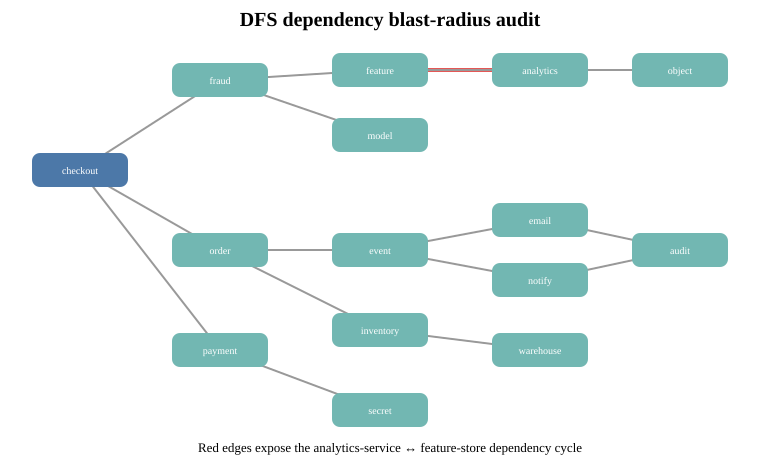

In [4]:
# Visualise the downstream blast radius and cycle.
affected=set(order); H=DG.subgraph(affected).copy()
pos=nx.spring_layout(H,seed=7)
plt.figure(figsize=(14,9))
nx.draw(H,pos,with_labels=True,node_size=700,font_size=7,arrows=True)
plt.title('DFS production dependency audit from checkout-service')
plt.axis('off'); plt.show()

0    1
1    3
2    6
3    4
4    2
Name: services, dtype: int64


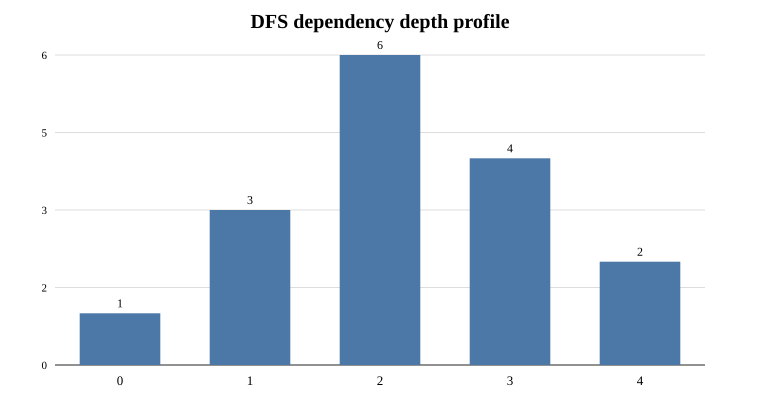

In [5]:
depth_counts=pd.Series(depth).value_counts().sort_index()
print(depth_counts.rename('services'))
plt.bar(depth_counts.index.astype(str),depth_counts.values)
plt.xlabel('DFS discovery depth'); plt.ylabel('Services discovered')
plt.title('Dependency depth profile'); plt.show()

## Interview takeaway
**Result:** DFS traced **16 downstream services**, reached depth **4**, and detected the explicit **analytics-service ↔ feature-store** cycle.

**CV bullet:** Built a DFS-based microservice dependency auditor over a 30-service directed graph, tracing incident blast radius, detecting cyclic dependencies and visualising depth/impact for production troubleshooting.